# Part 2 — Supervised Machine Learning Model — Build, Train, and Evaluate

In [3]:

# Task 1: Load the cleaned dataset

import pandas as pd
df = pd.read_csv('C:\\Users\\durga\\Desktop\\Capstone Pro\\capstone-ai-ml\\part1\\cleaned_data.csv') 

# Regression target
y_reg = df["GPA"] 

# Classification target (derived from y_reg)

risk_map = {"Low":0, "Medium":0, "High":1}
y_clf = df["Mental_Health_Risk"].map(risk_map)

# Feature matrix
X = df.drop(columns=["GPA","Mental_Health_Risk"])

print("Feature Matrix Shape:", X.shape)
print("Regression Target Shape:", y_reg.shape)
print("Classification Target Shape:", y_clf.shape)
print("Median GPA:", y_reg.median())
print("y_clf distribution:\n", y_clf.value_counts())


Feature Matrix Shape: (2000, 15)
Regression Target Shape: (2000,)
Classification Target Shape: (2000,)
Median GPA: 2.56
y_clf distribution:
 Mental_Health_Risk
0    1320
1     680
Name: count, dtype: int64


In [4]:
# Task 2: Encoding Categorical Columns

# Label Encoding for Ordinal Columns
# Student_ID is not needed for the model, we can drop it if present
if "Student_ID" in X.columns:
    X = X.drop(columns=["Student_ID"])

# Define mapping dictionaries to preserve natural order
activity_map = {'Low': 0, 'Moderate': 1, 'High': 2}
diet_map = {'Poor': 0, 'Average': 1, 'Good': 2} 
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}

# Apply mappings to the ordinal columns
X['Physical_Activity'] = X['Physical_Activity'].map(activity_map)
X['Diet_Quality'] = X['Diet_Quality'].map(diet_map)

# One-Hot Encoding for Nominal Columns
nominal_cols = ['Gender', 'Part_Time_Job', 'Previous_Mental_Health_History']

# Apply one-hot encoding and drop the first column to avoid multicollinearity
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

# Ensure all boolean columns created by get_dummies are converted to integers (0/1)
X = X.astype(int, errors='ignore') 

print(X.head())
print(X.shape)

   Age  Year_of_Study  Sleep_Hours  Study_Hours_Per_Week  Social_Media_Hours  \
0   22              3            6                    17                   6   
1   21              4            5                    22                   7   
2   22              5            7                    28                   6   
3   24              1            4                    14                   5   
4   20              1            6                    17                   4   

   Screen_Time_Hours  Physical_Activity  Financial_Stress  Family_Support  \
0                  7                  1                 8               4   
1                 11                  0                 4               5   
2                  8                  0                 4               6   
3                  7                  2                 3               8   
4                  7                  1                 8               7   

   Attendance_Rate  Diet_Quality  Gender_Male  Gender_No

In [5]:
print(X.dtypes)

Age                                   int64
Year_of_Study                         int64
Sleep_Hours                           int64
Study_Hours_Per_Week                  int64
Social_Media_Hours                    int64
Screen_Time_Hours                     int64
Physical_Activity                     int64
Financial_Stress                      int64
Family_Support                        int64
Attendance_Rate                       int64
Diet_Quality                          int64
Gender_Male                           int64
Gender_Non-binary                     int64
Part_Time_Job_Yes                     int64
Previous_Mental_Health_History_Yes    int64
dtype: object


In [6]:
# Task 3: Leak-free train-test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(X, y_reg, y_clf, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()

# Fit the scaler ONLY on the training features to learn the mean and variance and transform it simultaneously.
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features using the scaler fitted ONLY on the training data.
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)



X_train_scaled shape: (1600, 15)
X_test_scaled shape: (400, 15)


In [7]:
# Task 4: Regression model — Linear Regression:

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Linear Regression
# Initialize and train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)

# Predict on the scaled test set
y_pred_reg = lin_reg.predict(X_test_scaled)

# Compute MSE and R-squared
mse_lin = mean_squared_error(y_reg_test, y_pred_reg)
r2_lin = r2_score(y_reg_test, y_pred_reg)

print("--- Linear Regression Metrics ---")
print(f"MSE: {mse_lin:.4f}")
print(f"R²: {r2_lin:.4f}\n")

# Extract and print coefficients
feature_names = X.columns
coefficients = lin_reg.coef_

# Create a DataFrame for cleaner viewing and sorting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

print("--- Model Coefficients ---")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

# Identify the three features with the largest absolute coefficients
top_3_features = coef_df.sort_values(by='Absolute_Coefficient', ascending=False).head(3)

print("\n--- Top 3 Features (by absolute coefficient size) ---")
print(top_3_features[['Feature', 'Coefficient']].to_string(index=False))
print("\n")

# Ridge Regression
# Initialize and train the Ridge model
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_scaled, y_reg_train)

# Predict and evaluate
y_pred_ridge = ridge_reg.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

print("--- Ridge Regression Metrics ---")
print(f"MSE: {mse_ridge:.4f}")
print(f"R²: {r2_ridge:.4f}")

--- Linear Regression Metrics ---
MSE: 0.0874
R²: 0.2936

--- Model Coefficients ---
                           Feature  Coefficient
                               Age     0.004234
                     Year_of_Study    -0.000964
                       Sleep_Hours     0.068857
              Study_Hours_Per_Week     0.158387
                Social_Media_Hours    -0.000290
                 Screen_Time_Hours     0.007865
                 Physical_Activity     0.004511
                  Financial_Stress     0.005079
                    Family_Support    -0.002661
                   Attendance_Rate     0.068841
                      Diet_Quality    -0.016403
                       Gender_Male    -0.007510
                 Gender_Non-binary    -0.001844
                 Part_Time_Job_Yes     0.004036
Previous_Mental_Health_History_Yes    -0.001500

--- Top 3 Features (by absolute coefficient size) ---
             Feature  Coefficient
Study_Hours_Per_Week     0.158387
         Sleep_Hours    

--- Class Balance in Training Set (%) ---
Mental_Health_Risk
0    66.4375
1    33.5625
Name: proportion, dtype: float64 

--- Confusion Matrix ---
[[231  26]
 [ 37 106]] 

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       257
           1       0.80      0.74      0.77       143

    accuracy                           0.84       400
   macro avg       0.83      0.82      0.83       400
weighted avg       0.84      0.84      0.84       400

--- ROC AUC Score: 0.9219 ---


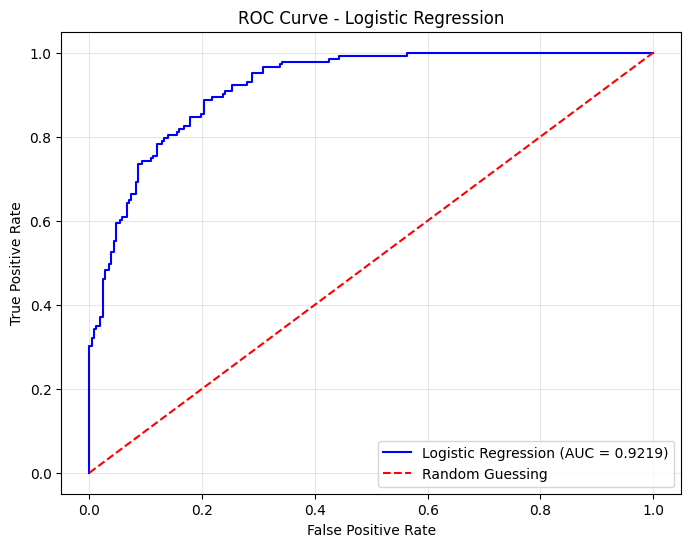

In [8]:
# Task 5: Classification model — Logistic Regression

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, roc_auc_score)

# Check class balance
class_percentages = y_clf_train.value_counts(normalize=True) * 100
print("--- Class Balance in Training Set (%) ---")
print(class_percentages, "\n")

# Train Logistic Regression
# proportional to class frequencies, handling any imbalance (< 35%).
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_clf_train)

# Predict labels and probabilities
y_pred_clf = log_reg.predict(X_test_scaled)
y_prob_clf = log_reg.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class (1)

# Compute and report metrics
conf_matrix = confusion_matrix(y_clf_test, y_pred_clf)
print("--- Confusion Matrix ---")
print(conf_matrix, "\n")

print("--- Classification Report ---")
print(classification_report(y_clf_test, y_pred_clf))

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_clf_test, y_prob_clf)
auc_score = roc_auc_score(y_clf_test, y_prob_clf)

print(f"--- ROC AUC Score: {auc_score:.4f} ---")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [9]:
# Task 5b: Decision-threshold sensitivity

from sklearn.metrics import precision_score, recall_score, f1_score

# Get predicted probabilities for the positive class (class 1)
y_prob_clf = log_reg.predict_proba(X_test_scaled)[:, 1]

# Define the thresholds to test
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

# Create an empty list to store the results
results = []

# Loop through each threshold and compute metrics

for thresh in thresholds:
    # Convert probabilities to class predictions based on the current threshold
    y_pred_adj = (y_prob_clf >= thresh).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_clf_test, y_pred_adj)
    recall = recall_score(y_clf_test, y_pred_adj)
    f1 = f1_score(y_clf_test, y_pred_adj)
    
    # Store the results
    results.append({
        'Threshold': f"{thresh:.2f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1': f"{f1:.4f}"
    })

results_df = pd.DataFrame(results)
print("--- Decision-Threshold Sensitivity Table ---")
print(results_df.to_string(index=False))

--- Decision-Threshold Sensitivity Table ---
Threshold Precision Recall     F1
     0.30    0.7118 0.8462 0.7732
     0.40    0.7651 0.7972 0.7808
     0.50    0.8030 0.7413 0.7709
     0.60    0.8261 0.6643 0.7364
     0.70    0.8710 0.5664 0.6864


In [10]:
# Task 6: Regularization Experiment: Logistic Regression (C=0.01)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Train a new model with strong regularization (C=0.01)
# Keeping class_weight='balanced' to remain consistent with the baseline model
log_reg_strong = LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, random_state=42)
log_reg_strong.fit(X_train_scaled, y_clf_train)

# Predict labels and probabilities
y_pred_strong = log_reg_strong.predict(X_test_scaled)
y_prob_strong = log_reg_strong.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
precision_strong = precision_score(y_clf_test, y_pred_strong)
recall_strong = recall_score(y_clf_test, y_pred_strong)
auc_strong = roc_auc_score(y_clf_test, y_prob_strong)

print("--- Regularized Model (C=0.01) Metrics ---")
print(f"Precision: {precision_strong:.4f}")
print(f"Recall: {recall_strong:.4f}")
print(f"AUC Score: {auc_strong:.4f}")

--- Regularized Model (C=0.01) Metrics ---
Precision: 0.7101
Recall: 0.8392
AUC Score: 0.9182


In [11]:
# Task 7: Bootstrap Sampling for AUC Difference 

# Convert to numpy arrays for safe integer array indexing
y_test_arr = np.array(y_clf_test)
y_prob_base_arr = np.array(y_prob_clf) # Probabilities from C=1.0 model
y_prob_strong_arr = np.array(y_prob_strong) # Probabilities from C=0.01 model

n_iterations = 500
auc_differences = []

# Set random seed for reproducibility
np.random.seed(42)

# Bootstrap sampling loop
for i in range(n_iterations):
    # Sample row indices with replacement
    indices = np.random.choice(len(y_test_arr), size=len(y_test_arr), replace=True)
    
    y_test_sample = y_test_arr[indices]
    
    # Check to ensure the bootstrap sample has both classes (0 and 1) 
    # AUC calculation will fail if a sample randomly gets only one class
    if len(np.unique(y_test_sample)) < 2:
        continue
        
    prob_base_sample = y_prob_base_arr[indices]
    prob_strong_sample = y_prob_strong_arr[indices]
    
    # Compute AUC for both models on this specific bootstrap sample
    auc_base = roc_auc_score(y_test_sample, prob_base_sample)
    auc_strong = roc_auc_score(y_test_sample, prob_strong_sample)
    
    # Compute the difference (C=1.0 minus C=0.01)
    auc_differences.append(auc_base - auc_strong)

# Compute mean and 95% confidence interval percentiles
mean_diff = np.mean(auc_differences)
ci_lower = np.percentile(auc_differences, 2.5)
ci_upper = np.percentile(auc_differences, 97.5)

print("--- Bootstrap AUC Difference (C=1.0 vs C=0.01) ---")
print(f"Mean AUC Difference: {mean_diff:.4f}")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

if ci_lower > 0 or ci_upper < 0:
    print("The 95% confidence interval excludes zero.")
    print("The C=1.0 model consistently outperforms the C=0.01 model.")
else:
    print("The 95% confidence interval includes zero.")
    print("The performance difference may not be statistically reliable.")

--- Bootstrap AUC Difference (C=1.0 vs C=0.01) ---
Mean AUC Difference: 0.0036
95% Confidence Interval: [-0.0003, 0.0079]
The 95% confidence interval includes zero.
The performance difference may not be statistically reliable.


In [12]:
import joblib

joblib.dump(X_train_scaled, 'X_train_scaled.pkl')
joblib.dump(X_test_scaled, 'X_test_scaled.pkl')
joblib.dump(y_clf_train, 'y_clf_train.pkl')
joblib.dump(y_clf_test, 'y_clf_test.pkl')

['y_clf_test.pkl']